# Task 2 — boxed ascent-condition figure (editable)

Reproduces `script/inr_sample/task2-alignment-tk-figure.py` cell-by-cell so you can restyle it
directly without touching the CLI script.

**Run from the repo root** (`/hpcgpfs01/scratch/gzhao/inr_sampling`) so the relative JSON paths resolve
— the next cell finds it automatically regardless of where Jupyter was launched from.

Background: `Agent-report/task2-alignment-boiling.md` (full writeup) and
`Agent-report/Future Paper/prove-suboptimality.md` (the theorem this verifies).

Plots (budget-matched partition only, iter=5/pct=10/soft):
- **(a)** `dF(w(alpha))/dalpha |_{alpha=0} = C * sum_k t_k log||r_bar_k||`, `C = 2||g||^2/(||g||^2+V)^2 > 0`
  — the first-order slope of the `S_w^2/G_w` proxy at the unbiased point, along the residual-power
  weighting family. Positive <=> a small `alpha>0` beats `alpha=0`. Verified positive in 60/60
  (run x checkpoint x dataset) combinations on this partition — see `task2-alignment-tk.py`.
- **(b)** `Spearman rho(t_k, log||r_bar_k||)` — the same sign, scale-free, in `[-1, 1]`.

Both panels: mean +/- range (min-max) over the 5 time-frame runs per dataset.

**Style matched to** `NIPS-2026-INR-Sampling/figure/proxy_metrics_rank_topk.pdf`: plain matplotlib
look (box spines on all sides, no gridlines, default fonts/legend chrome), `steelblue` /
`darkorange` series colors (sampled directly from that PDF's render), ~15% alpha shaded range
bands (also measured from it), centered per-panel titles in the same
`"$X$ vs $Y$: description"` phrasing, circle markers.

In [2]:
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

### Repo root

Jupyter's working directory is wherever the server was *launched* from, not this notebook's own
folder — so the relative paths below only resolve if that happens to be the repo root. This cell
finds it regardless of launch directory: tries the known checkout path first, then searches upward
from the current working directory for the `Agent-report/` folder, and `chdir`s there. If neither
works (e.g. a different checkout), edit `REPO_ROOT` directly.

In [3]:
import os
from pathlib import Path

REPO_ROOT = Path("/hpcgpfs01/scratch/gzhao/inr_sampling")  # edit if your checkout lives elsewhere
if not (REPO_ROOT / "Agent-report").is_dir():
    for _p in [Path.cwd(), *Path.cwd().parents]:
        if (_p / "Agent-report").is_dir():
            REPO_ROOT = _p
            break
    else:
        raise FileNotFoundError(
            "Could not find the repo root (looked for an Agent-report/ folder above "
            f"{Path.cwd()}). Set REPO_ROOT to your checkout path manually."
        )
os.chdir(REPO_ROOT)
print("cwd ->", Path.cwd())

cwd -> /hpcgpfs01/scratch/gzhao/inr_sampling


## 1. Inputs

Two raw JSONs from `task2-alignment-tk.py` — the **budget-matched (iter 5)** partition only for
each dataset. (The as-trained/iter-8 files exist too — `task2-alignment-tk-boiling.json` /
`task2-alignment-tk-ns1024.json` — swap them in below if you want that partition instead; the
earlier 4-line/2-partition version of this figure is preserved in git history.)

Each file is keyed by `"<checkpoint_dir>|<epoch>"` and holds, per run: `gnorm2` (`||g||^2`), `V`,
`boxed_stat` (`sum_k t_k log||r_bar_k||`), `rho_t_logA` (`Spearman rho(t_k, log||r_bar_k||)`), plus
diagnostics (`sum_t_over_scale`, `frac_sigma2_negative`, ...).

In [4]:
PATHS = {
    "boiling": "Agent-report/raw/task2-alignment-tk-boiling-iter5.json",
    "ns1024": "Agent-report/raw/task2-alignment-tk-ns1024-iter5.json",
}
OUT_PATH = "Agent-report/task2-alignment-tk-curve.png"  # overwrite in place, or point elsewhere

## 2. Style

Colors sampled directly from the reference PDF's rendered pixels (matplotlib *named* colors, not
the tab10 default cycle):

```python
from PIL import Image
from collections import Counter
im = Image.open("reference_render.png").convert("RGB")  # rasterize the PDF first, e.g. via ImageMagick `convert`
Counter(im.getdata()).most_common(20)   # -> (70,130,180)=#4682b4='steelblue', (255,140,0)=#ff8c00='darkorange'
```

The shaded-band alpha (`BAND_ALPHA`) was recovered the same way: sample a pixel inside a band, away
from any line/marker, and solve `blended = alpha*fg + (1-alpha)*white` per channel (gives ~0.15
for both series, consistently).

In [5]:
# --- series: (key, legend label, color, path) --------------------------------------------------
COL_BOILING = "steelblue"
COL_NS1024 = "darkorange"
BAND_ALPHA = 0.15  # matches the reference figure's shaded-range bands (measured from its render)

SERIES = [
    ("boiling", "PoolBoiling2D", COL_BOILING, PATHS["boiling"]),
    ("ns1024", "NS2D", COL_NS1024, PATHS["ns1024"]),
]

## 3. Load

`C = 2||g||^2 / (||g||^2 + V)^2` is the theorem's own sign-preserving prefactor (always positive);
multiplying `boxed_stat` by it turns the abstract sum into an actual derivative, in interpretable
units, without changing its sign. Delete the `C *` below to plot the raw `boxed_stat` instead.

In [6]:
def load(path):
    raw = json.load(open(path))
    by_epoch = defaultdict(list)
    for v in raw.values():
        C = 2 * v["gnorm2"] / (v["gnorm2"] + v["V"]) ** 2
        deriv = C * v["boxed_stat"]
        by_epoch[v["epoch"]].append({"deriv": deriv, "rho": v["rho_t_logA"]})
    epochs = sorted(by_epoch)
    stats = {}
    for ep in epochs:
        rows = by_epoch[ep]
        stats[ep] = {
            "deriv_mean": np.mean([r["deriv"] for r in rows]),
            "deriv_lo": np.min([r["deriv"] for r in rows]),
            "deriv_hi": np.max([r["deriv"] for r in rows]),
            "rho_mean": np.mean([r["rho"] for r in rows]),
            "rho_lo": np.min([r["rho"] for r in rows]),
            "rho_hi": np.max([r["rho"] for r in rows]),
        }
    return epochs, stats


data = {name: load(path) for name, _, _, path in SERIES}
{name: {ep: round(s["deriv_mean"], 6) for ep, s in stats.items()} for name, (epochs, stats) in data.items()}

{'boiling': {100: 0.001152,
  300: 2.2e-05,
  1000: 7e-06,
  2000: 6e-06,
  4000: 5e-06,
  4999: 5e-06},
 'ns1024': {100: 67.999641,
  300: 284.051222,
  1000: 64.217784,
  2000: 19.074317,
  4000: 5.905467,
  4999: 4.180185}}

## 4. Plot

One figure, two panels, one y-axis each (no dual-axis). Note panel (a) is **log-y by necessity**
(values span ~1e-8 to ~1e2 across the two datasets) — a linear axis would squash everything to the
baseline and hide the "always positive" result the panel exists to show; that's a data constraint,
not a style deviation from the reference. The x-ticks are left to matplotlib's automatic locator
(round numbers, matching the reference) rather than forced onto the actual — unevenly spaced —
checkpoint epochs, which collide as text (`100`/`300` overlap) if forced.

Edit freely below — e.g. `figsize`, `BAND_ALPHA`, marker size, legend `loc`, titles, or add a third
panel.

figure -> Agent-report/task2-alignment-tk-curve.png


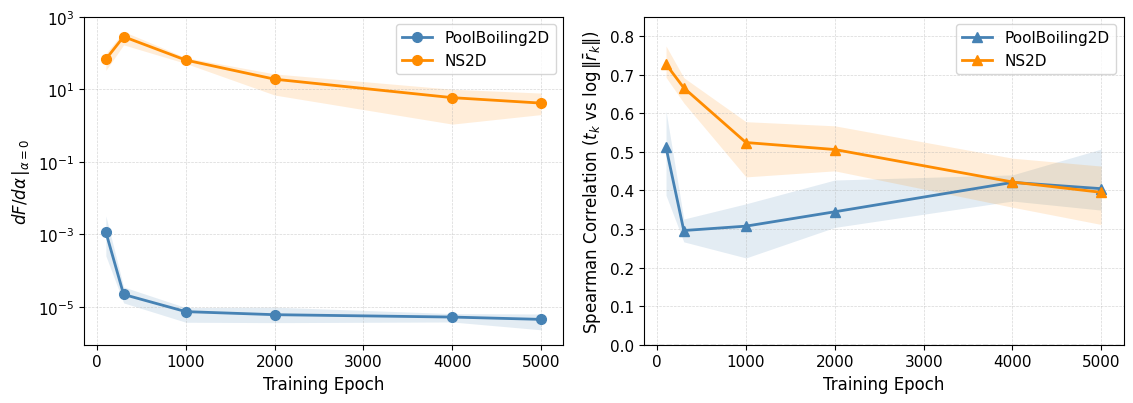

In [12]:
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
                      "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.2))

# ---- panel (a): dF/dalpha|_0, log-y (necessary: spans ~1e-8 to ~1e2 across the two datasets) -----
for name, label, color, _ in SERIES:
    epochs, stats = data[name]
    y = [stats[e]["deriv_mean"] for e in epochs]
    lo = [stats[e]["deriv_lo"] for e in epochs]
    hi = [stats[e]["deriv_hi"] for e in epochs]
    axL.fill_between(epochs, lo, hi, color=color, alpha=BAND_ALPHA, linewidth=0)
    axL.plot(epochs, y, "-o", color=color, lw=2, ms=7, label=label)

axL.set_yscale("log")
axL.set_xlabel("Training Epoch")
axL.set_ylabel(r"$dF/d\alpha\,|_{\alpha=0}$")
# axL.set_title(r"$t_k$ vs $\log\|\bar r_k\|$: Ascent Slope")
axL.legend(loc="upper right")
axL.set_xlim(-150, 5250)

# ---- panel (b): rho(t_k, log||r_bar_k||), linear y in [-1,1] -------------------------------------
for name, label, color, _ in SERIES:
    epochs, stats = data[name]
    y = [stats[e]["rho_mean"] for e in epochs]
    lo = [stats[e]["rho_lo"] for e in epochs]
    hi = [stats[e]["rho_hi"] for e in epochs]
    axR.fill_between(epochs, lo, hi, color=color, alpha=BAND_ALPHA, linewidth=0)
    axR.plot(epochs, y, "-^", color=color, lw=2, ms=7, label=label)

axR.axhline(0, color="0.6", lw=1, ls="--", zorder=1)
axR.set_ylim(0.0, 0.85)
axR.set_xlabel("Training Epoch")
axR.set_ylabel(r"Spearman Correlation ($t_k$ vs $\log\|\bar r_k\|$)")
# axR.set_title(r"$t_k$ vs $\log\|\bar r_k\|$: Rank Correlation")
axR.legend(loc="upper right")
axR.set_xlim(-150, 5250)
axR.grid(True, ls="--", lw=0.5, alpha=0.5)
axL.grid(True, ls="--", lw=0.5, alpha=0.5)

fig.tight_layout()
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"figure -> {OUT_PATH}")

## 5. Sanity check (optional)

`sum_k t_k == 0` is an exact identity of the construction (see `task2-alignment-tk.py`); this
re-checks it directly from the saved diagnostics, and reports how many (dataset, run, checkpoint)
combinations have `boxed_stat > 0` — should be 60/60 on this (budget-matched) partition.

In [8]:
n_pos = n_tot = 0
max_identity_err = 0.0
for name, _, _, path in SERIES:
    raw = json.load(open(path))
    for v in raw.values():
        n_tot += 1
        n_pos += v["boxed_stat"] > 0
        max_identity_err = max(max_identity_err, abs(v["sum_t_over_scale"]))
print(f"boxed_stat > 0 in {n_pos}/{n_tot}; max |sum_k t_k| / sum_k |t_k| = {max_identity_err:.1e}")

boxed_stat > 0 in 60/60; max |sum_k t_k| / sum_k |t_k| = 3.2e-16
